In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


### Basic Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [5]:
# To check count of NULLs column wise
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

#### 1. Which team won the most matches?

Text(0.5, 1.0, 'Teams won matches')

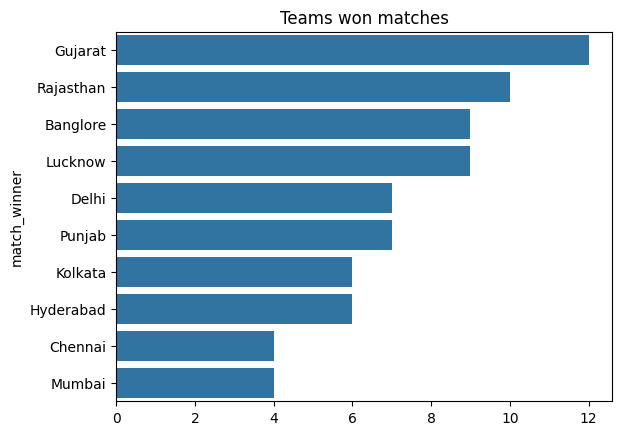

In [6]:
match_wins=df['match_winner'].value_counts()
sns.barplot(y=match_wins.index, x=match_wins.values)
plt.title("Teams won matches")

#### 2. Toss decision trends

Text(0.5, 1.0, 'Toss decision trend')

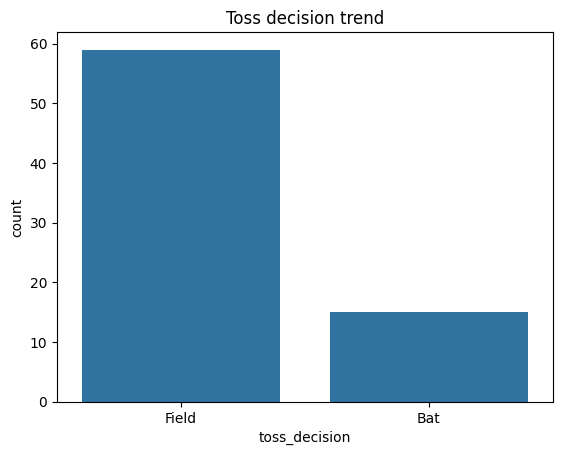

In [7]:
sns.countplot(x=df["toss_decision"])
plt.title("Toss decision trend")

#### 3. Toss winner vs Match winner

In [8]:
count=df[df["toss_winner"]==df["match_winner"]]["match_id"].count()
percentage=(count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

#### 4. How do teams win? (Runs vs Wickets)

<Axes: xlabel='won_by', ylabel='count'>

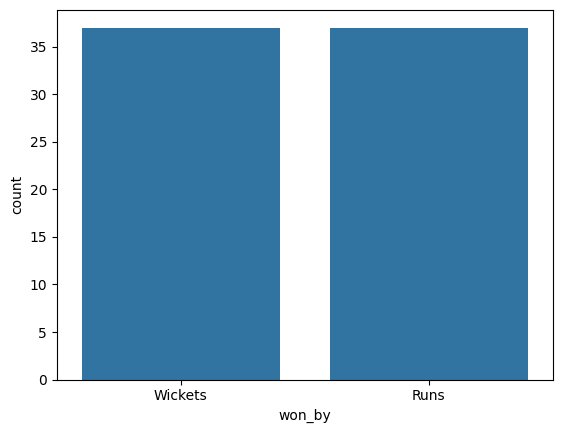

In [9]:
sns.countplot(x=df["won_by"])

#### 5. Key player performances

In [10]:
count=df["player_of_the_match"].value_counts().head(10)

<Axes: ylabel='player_of_the_match'>

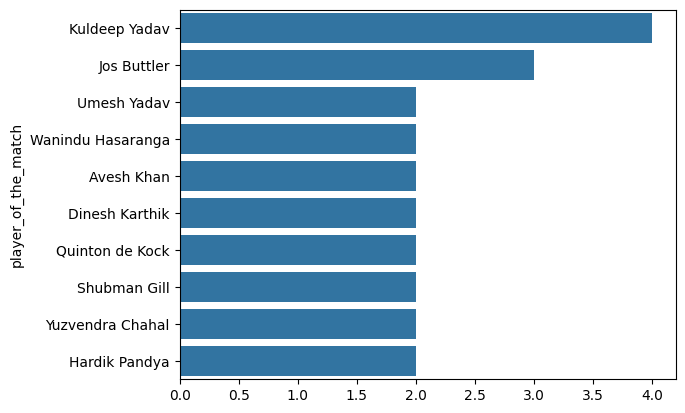

In [11]:
sns.barplot(x=count.values,y=count.index)

#### 6. Top scorers

In [19]:
high=df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(5)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

#### 7. 10 best bowling figures

<Axes: ylabel='best_bowling'>

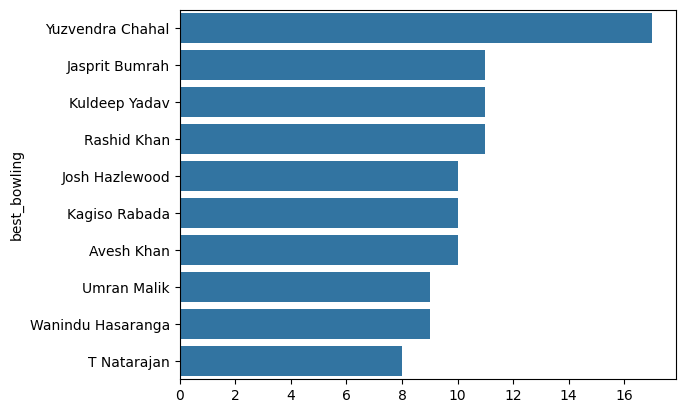

In [29]:
df["highest_wickets"]=df["best_bowling_figure"].apply(lambda x:x.split("--")[0])
df["highest_wickets"]=df["highest_wickets"].astype(int)
bowlers=df.groupby("best_bowling")["highest_wickets"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=bowlers.values, y=bowlers.index)

#### 8. Most matches played by vanue

<Axes: ylabel='venue'>

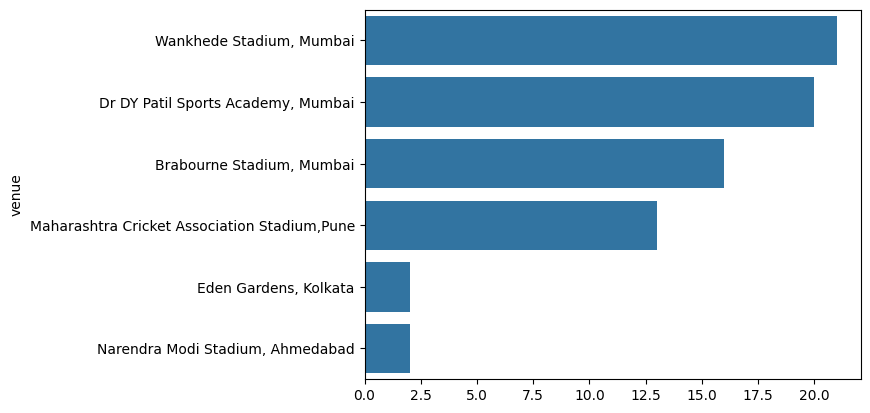

In [35]:
vanues=df["venue"].value_counts()
sns.barplot(x=vanues.values, y=vanues.index)

#### 9. Who won the highest margin by runs

In [48]:
df[df["won_by"]=="Runs"].sort_values(by="margin", ascending=False).head(1)[["match_winner", "margin"]]

,match_winner,margin
54,Chennai,91


#### 10. Which player has highest individual score?

In [56]:
df[df["highscore"]==df["highscore"].max()][["top_scorer", "highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140


#### 11. Which bowlers had the best bowling figures?

In [60]:
df[df["highest_wickets"]==df["highest_wickets"].max()][["best_bowling", "best_bowling_figure"]]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
